# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np

from matplotlib import pyplot as plt

from kidney.model_configuration import ANALYSIS_TO_OUTCOME
from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot, plot_ppc

## Configuration

In [2]:
az.rcParams["data.load"] = "eager"

## BFI analysis

In [3]:
msts_bfi_vehicle = pl.read_csv(PREPARED_FILES["bfi_vehicle"])
msts_bfi_empa = pl.read_csv(PREPARED_FILES["bfi_empa"])
msts_bfi_vehicle.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,treatment,bfi_baseline,bfi_change,bfi_injected,log_bfi_baseline,log_bfi_injected,log_bfi_baseline_std,log_bfi_change
str,f64,str,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64
"""count""",763.0,"""763""","""763""","""763""","""763""",763.0,"""763""",763.0,763.0,763.0,763.0,763.0,763.0,763.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",396.760157,null,null,null,null,12.087811,null,60.508247,3.396842,63.905089,4.082197,4.135394,-0.087787,0.053196
"""std""",225.030033,null,null,null,null,8.071947,null,12.346811,3.832176,13.554967,0.203315,0.209763,0.978514,0.059407
"""min""",15.0,"""20240813a""","""fa/+""","""Adult""","""F""",0.0,"""Vehicle""",29.043812,-7.538559,33.834568,3.368805,3.521483,-3.521196,-0.11578
"""25%""",205.0,null,null,null,null,5.0,null,50.708885,0.664391,53.904743,3.926101,3.987218,-0.839046,0.011429
"""50%""",385.0,null,null,null,null,11.0,null,59.074081,3.135319,61.920944,4.078792,4.125858,-0.104175,0.051714
"""75%""",589.0,null,null,null,null,18.0,null,68.218925,6.059395,72.643837,4.222722,4.285569,0.588529,0.098368
"""max""",825.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,"""Vehicle""",102.490929,20.555809,109.41053,4.629774,4.695107,2.547588,0.251871


In [4]:
idata_bfi_empa = az.from_netcdf(RESULTS_DIR / "idata_bfi_empa_log.nc")
idata_bfi_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bfi_vehicle_log.nc")
idata_bfi_empa

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [5]:
az.summary(idata_bfi_empa, var_names=["~mu", "~1|rat"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.025,0.001,0.024,0.026,0.000,0.000,3177.0,2303.0,1.00
Intercept,-0.159,0.021,-0.198,-0.118,0.001,0.000,1312.0,1721.0,1.00
gtyp[fa/fa],0.083,0.033,0.023,0.147,0.001,0.001,1350.0,1670.0,1.00
age[Young],0.016,0.032,-0.040,0.079,0.001,0.001,1351.0,1564.0,1.01
sex[M],-0.031,0.030,-0.087,0.025,0.001,0.001,1377.0,1570.0,1.00
"gtyp:age[fa/fa, Young]",-0.036,0.044,-0.122,0.043,0.001,0.001,1377.0,1677.0,1.00
"gtyp:sex[fa/fa, M]",0.019,0.044,-0.055,0.107,0.001,0.001,1386.0,1745.0,1.00
1|rat_sigma,0.061,0.008,0.046,0.077,0.000,0.000,946.0,1486.0,1.00


In [6]:
az.summary(idata_bfi_vehicle, var_names=["~mu", "~1|rat"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.023,0.001,0.022,0.024,0.000,0.000,2567.0,2265.0,1.01
Intercept,0.085,0.018,0.051,0.119,0.001,0.000,1192.0,1547.0,1.00
gtyp[fa/fa],-0.023,0.026,-0.073,0.025,0.001,0.001,1308.0,1673.0,1.00
age[Young],0.033,0.027,-0.019,0.080,0.001,0.001,1384.0,1655.0,1.00
sex[M],-0.097,0.026,-0.146,-0.048,0.001,0.001,1267.0,1472.0,1.00
"gtyp:age[fa/fa, Young]",-0.031,0.036,-0.100,0.036,0.001,0.001,1253.0,1776.0,1.00
"gtyp:sex[fa/fa, M]",0.066,0.035,-0.006,0.129,0.001,0.001,1405.0,1482.0,1.00
1|rat_sigma,0.050,0.007,0.037,0.063,0.000,0.000,925.0,1510.0,1.00


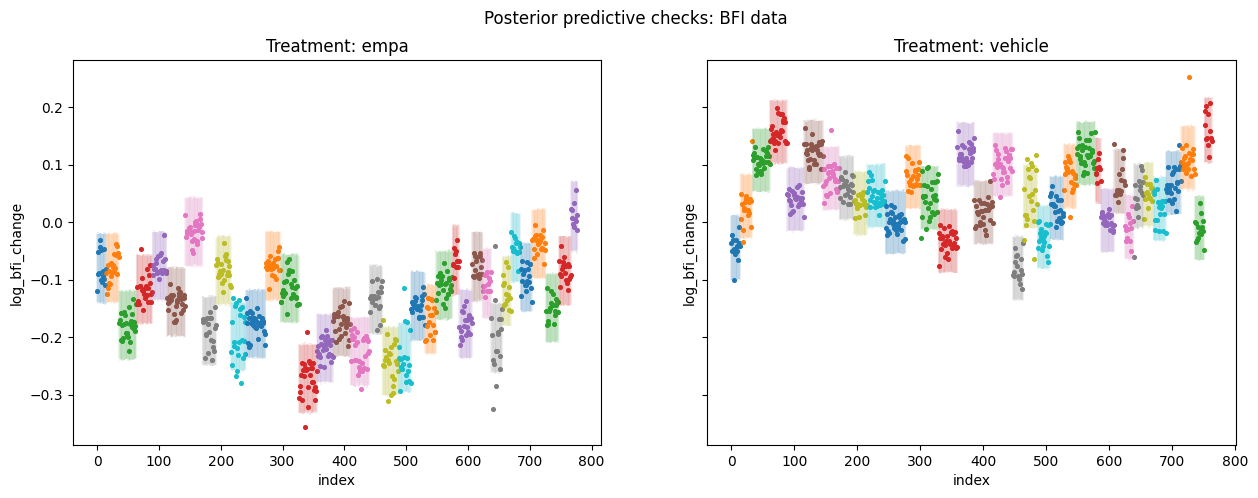

In [7]:
f, axes = plt.subplots(1, 2, figsize=[15, 5], sharey=True)
axes[0] = plot_ppc(axes[0], idata_bfi_empa, msts_bfi_empa, ycol="log_bfi_change", groupcol="rat")
axes[0].set_title("Treatment: empa");
axes[0].get_legend().remove()

axes[1] = plot_ppc(axes[1], idata_bfi_vehicle, msts_bfi_vehicle, ycol="log_bfi_change", groupcol="rat")
axes[1].set_title("Treatment: vehicle");
axes[1].get_legend().remove()

f.suptitle("Posterior predictive checks: BFI data");
f.savefig(PLOT_DIR / "ppc_bfi.png", bbox_inches="tight", dpi=200)

In [8]:
t_groups_empa, t_groups_vehicle = (
    {
        "fa/fa:young": idata.posterior["age"] + idata.posterior["gtyp"] + idata.posterior["gtyp:age"],
        "fa/fa:old": idata.posterior["gtyp"],
        "fa/+:old": 0.0,
        "fa/+:young": idata.posterior["age"],    
    } 
    for idata in (idata_bfi_empa, idata_bfi_vehicle)
)
ts_empa, ts_vehicle = (
    {
        "fa/fa given young": t_groups["fa/fa:young"] - t_groups["fa/+:young"],
        "fa/fa given old": t_groups["fa/fa:old"] - t_groups["fa/+:old"],
        "young given fa/fa": t_groups["fa/fa:young"] - t_groups["fa/fa:old"],
        "young given fa/+": t_groups["fa/+:young"] - t_groups["fa/+:old"],
    }
    for t_groups in (t_groups_empa, t_groups_vehicle)
)
def get_sign_probs(ts):
    return {k: (v>0).mean().item() for k, v in ts.items()}

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa given young': 0.87375,
 'fa/fa given old': 0.99425,
 'young given fa/fa': 0.2505,
 'young given fa/+': 0.704}


Vehicle sign probabilities:


{'fa/fa given young': 0.05325,
 'fa/fa given old': 0.187,
 'young given fa/fa': 0.54925,
 'young given fa/+': 0.90225}

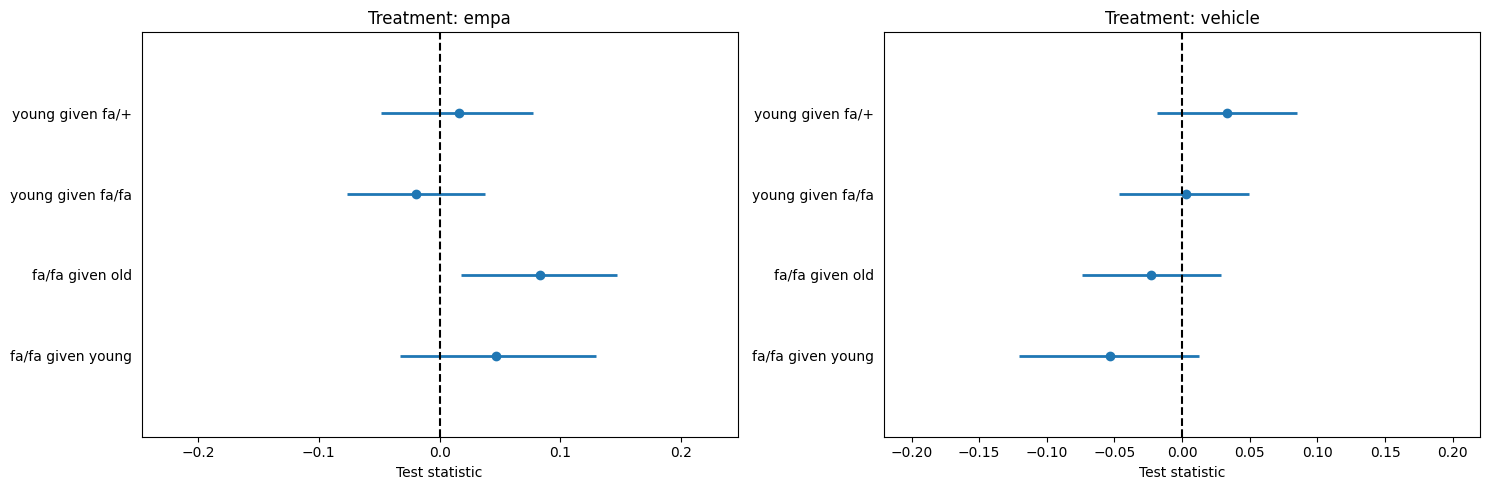

In [9]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0] = forestplot(axes[0], ts_empa);
axes[0].set_title("Treatment: empa");

axes[1] = forestplot(axes[1], ts_vehicle);
axes[1].set_title("Treatment: vehicle");

f.tight_layout()
f.savefig(PLOT_DIR / "ts_bfi.png", bbox_inches="tight", dpi=200)

## Frequency

In [10]:
msts_frequency = pl.read_csv(PREPARED_FILES["frequency"])
msts_frequency.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,frequency_empa,frequency_vehicle,frequency_change,frequency_vehicle_std,frequency_empa_std,frequency_change_std,log_frequency_vehicle,log_frequency_empa,log_frequency_vehicle_std,log_frequency_change
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",229.0,"""229""","""229""","""229""","""229""",229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",285.279476,null,null,null,null,12.218341,0.029575,0.026958,0.002617,-3.7234e-16,1.2411e-16,-6.2056e-17,-3.624209,-3.533741,-4.5301e-15,0.090468
"""std""",158.105563,null,null,null,null,7.719048,0.0045,0.00384,0.002757,1.0,1.0,1.0,0.149548,0.166347,1.0,0.102385
"""min""",3.0,"""20240814a""","""fa/+""","""Adult""","""F""",0.0,0.015708,0.015634,-0.011551,-2.949113,-3.081311,-5.138784,-4.158299,-4.153608,-3.571348,-0.436914
"""25%""",130.0,null,null,null,null,6.0,0.026423,0.024266,0.001281,-0.70094,-0.700319,-0.484396,-3.718664,-3.633521,-0.6316,0.045953
"""50%""",287.0,null,null,null,null,12.0,0.02996,0.026984,0.002494,0.006762,0.085685,-0.044437,-3.612522,-3.507883,0.07815,0.086278
"""75%""",428.0,null,null,null,null,17.0,0.032916,0.029501,0.003881,0.662343,0.742474,0.458477,-3.523334,-3.413794,0.674533,0.133595
"""max""",537.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,0.038459,0.036252,0.013356,2.420488,1.974127,3.895263,-3.317272,-3.258164,2.052429,0.46905


In [11]:
idata_frequency = az.from_netcdf(RESULTS_DIR / "idata_frequency_lin.nc")
idata_frequency

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [12]:
az.summary(idata_frequency, var_names=["~mu", "~1|rat"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.001,0.000,0.001,0.002,0.0,0.0,5125.0,2874.0,1.0
Intercept,0.004,0.001,0.002,0.006,0.0,0.0,1775.0,2334.0,1.0
gtyp[fa/fa],-0.002,0.001,-0.005,0.001,0.0,0.0,2041.0,2120.0,1.0
age[Young],-0.001,0.002,-0.005,0.002,0.0,0.0,2429.0,1959.0,1.0
sex[M],0.001,0.002,-0.002,0.004,0.0,0.0,2419.0,2164.0,1.0
"gtyp:age[fa/fa, Young]",0.003,0.002,-0.001,0.007,0.0,0.0,2320.0,2327.0,1.0
"gtyp:sex[fa/fa, M]",-0.007,0.002,-0.011,-0.003,0.0,0.0,2403.0,2330.0,1.0
1|rat_sigma,0.002,0.000,0.001,0.003,0.0,0.0,1613.0,2138.0,1.0


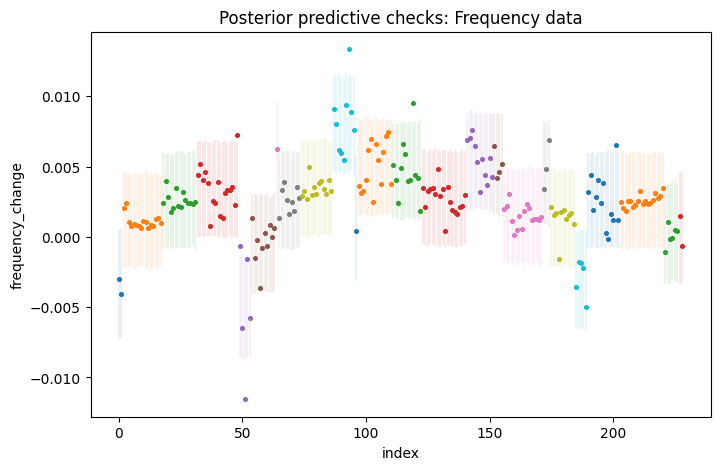

In [13]:
f, ax = plt.subplots(figsize=[8, 5])
ax = plot_ppc(ax, idata_frequency, msts_frequency, ycol="frequency_change", groupcol="rat")
ax.get_legend().remove()
ax.set_title("Posterior predictive checks: Frequency data");
f.savefig(PLOT_DIR / "ppc_frequency.png", bbox_inches="tight", dpi=200)

In [14]:
t_groups_frequency = {
    "fa/fa:male": idata_frequency.posterior["gtyp"] + idata_frequency.posterior["sex"] + idata_frequency.posterior["gtyp:sex"],
    "fa/+:male": idata_frequency.posterior["sex"],
    "fa/fa:female": idata_frequency.posterior["gtyp"],
    "fa/+:female": 0.0,
    "fa/fa:young": idata_frequency.posterior["gtyp"] + idata_frequency.posterior["age"] + idata_frequency.posterior["gtyp:age"],
    "fa/+:young": idata_frequency.posterior["age"],    
    "fa/fa:old": idata_frequency.posterior["gtyp"],
    "fa/+:old": 0.0,
} 
ts_frequency = {
    "fa/fa given male": t_groups_frequency["fa/fa:male"] - t_groups_frequency["fa/+:male"],
    "fa/fa given female": t_groups_frequency["fa/fa:female"] - t_groups_frequency["fa/+:female"],
    "fa/fa given young": t_groups_frequency["fa/fa:young"] - t_groups_frequency["fa/+:young"],
    "fa/fa given old": t_groups_frequency["fa/fa:old"] - t_groups_frequency["fa/+:old"],
    "young given fa/fa": t_groups_frequency["fa/fa:young"] - t_groups_frequency["fa/fa:old"],
    "young given fa/+": t_groups_frequency["fa/+:young"] - t_groups_frequency["fa/+:old"],
}
print("Sign probabilities:")
display(get_sign_probs(ts_frequency))

Sign probabilities:


{'fa/fa given male': 0.00025,
 'fa/fa given female': 0.0785,
 'fa/fa given young': 0.76,
 'fa/fa given old': 0.0785,
 'young given fa/fa': 0.8935,
 'young given fa/+': 0.1865}

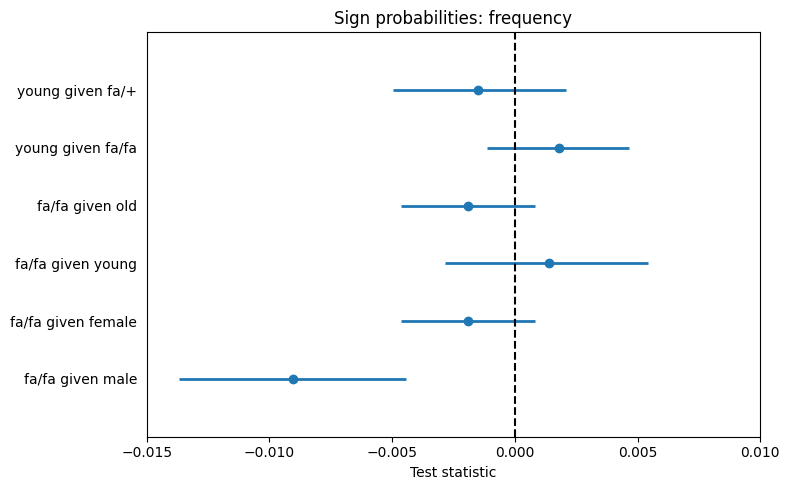

In [15]:
f, ax = plt.subplots(figsize=(8, 5))
ax = forestplot(ax, ts_frequency);
ax.set_title("Sign probabilities: frequency");
ax.set_xlim(-0.015, 0.01)
f.tight_layout()
f.savefig(PLOT_DIR / "ts_frequency.png", bbox_inches="tight", dpi=200)

## Power

In [16]:
msts_power = pl.read_csv(PREPARED_FILES["power"])
msts_power.describe()

statistic,,rat,gtyp,age,sex,vessel_idx,power_empa,power_vehicle,power_ratio,power_change,power_vehicle_std,power_empa_std,power_change_std,log_power_vehicle,log_power_empa,log_power_vehicle_std,log_power_change
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",725.0,"""725""","""725""","""725""","""725""",725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0,725.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",396.801379,null,null,null,null,11.944828,8.160552,17.184354,0.565412,-9.023802,2.5482e-16,9.8006e-17,1.5681e-16,2.490881,1.737094,-3.9202e-16,-0.753787
"""std""",231.511468,null,null,null,null,7.94315,8.155119,16.899861,0.325091,12.873524,1.0,1.0,1.0,0.8342,0.845396,1.0,0.666469
"""min""",0.0,"""20240813a""","""fa/+""","""Adult""","""F""",0.0,0.521412,1.606238,0.024145,-113.020245,-0.92179,-0.936729,-8.07832,0.473895,-0.651215,-2.41787,-3.723676
"""25%""",199.0,null,null,null,null,5.0,3.059968,6.680392,0.349868,-11.218514,-0.621541,-0.625446,-0.170483,1.899177,1.118404,-0.709308,-1.0502
"""50%""",392.0,null,null,null,null,11.0,5.595548,11.82154,0.52548,-5.423467,-0.317329,-0.314527,0.27967,2.469923,1.721971,-0.025123,-0.643442
"""75%""",590.0,null,null,null,null,18.0,10.600946,21.514314,0.717233,-2.104147,0.256213,0.299247,0.537511,3.068718,2.360943,0.692685,-0.332355
"""max""",815.0,"""20241030b""","""fa/fa""","""Young""","""M""",33.0,68.914547,118.211847,2.68275,7.781855,5.978007,7.449798,1.305443,4.772478,4.232867,2.735074,0.986843


In [17]:
idata_power = az.from_netcdf(RESULTS_DIR / "idata_power_log.nc")
idata_power

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [18]:
az.summary(idata_power, var_names=["~mu", "~1|rat"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.439,0.012,0.417,0.461,0.000,0.000,3319.0,2691.0,1.00
Intercept,-0.663,0.164,-0.977,-0.351,0.005,0.004,1240.0,1578.0,1.01
gtyp[fa/fa],0.169,0.258,-0.304,0.667,0.007,0.005,1218.0,1769.0,1.00
age[Young],-0.061,0.251,-0.509,0.413,0.007,0.006,1243.0,1321.0,1.00
sex[M],-0.531,0.237,-0.982,-0.101,0.006,0.005,1529.0,1958.0,1.00
"gtyp:age[fa/fa, Young]",0.129,0.342,-0.507,0.771,0.010,0.006,1285.0,1734.0,1.00
"gtyp:sex[fa/fa, M]",0.508,0.333,-0.155,1.110,0.009,0.007,1324.0,1632.0,1.00
1|rat_sigma,0.469,0.071,0.347,0.598,0.002,0.002,1269.0,1928.0,1.00


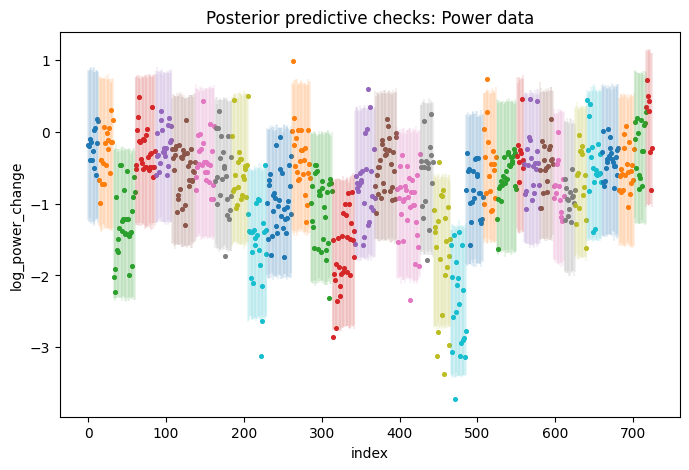

In [19]:
f, ax = plt.subplots(figsize=[8, 5])
ax = plot_ppc(ax, idata_power, msts_power, ycol="log_power_change", groupcol="rat")
ax.get_legend().remove()
ax.set_title("Posterior predictive checks: Power data");
f.savefig(PLOT_DIR / "ppc_power.png", bbox_inches="tight", dpi=200)

In [20]:
t_groups_power = {
    "fa/fa:male": idata_power.posterior["gtyp"] + idata_power.posterior["sex"] + idata_power.posterior["gtyp:sex"],
    "fa/+:male": idata_power.posterior["sex"],
    "fa/fa:female": idata_power.posterior["gtyp"],
    "fa/+:female": 0.0,
    "fa/fa:young": idata_power.posterior["gtyp"] + idata_power.posterior["age"] + idata_power.posterior["gtyp:age"],
    "fa/+:young": idata_power.posterior["age"],    
    "fa/fa:old": idata_power.posterior["gtyp"],
    "fa/+:old": 0.0,
} 
ts_power = {
    "fa/fa given male": t_groups_power["fa/fa:male"] - t_groups_power["fa/+:male"],
    "fa/fa given female": t_groups_power["fa/fa:female"] - t_groups_power["fa/+:female"],
    "fa/fa given young": t_groups_power["fa/fa:young"] - t_groups_power["fa/+:young"],
    "fa/fa given old": t_groups_power["fa/fa:old"] - t_groups_power["fa/+:old"],
    "young given fa/fa": t_groups_power["fa/fa:young"] - t_groups_power["fa/fa:old"],
    "young given fa/+": t_groups_power["fa/+:young"] - t_groups_power["fa/+:old"],
}
print("Sign probabilities:")
display(get_sign_probs(ts_power))


Sign probabilities:


{'fa/fa given male': 0.9905,
 'fa/fa given female': 0.746,
 'fa/fa given young': 0.8265,
 'fa/fa given old': 0.746,
 'young given fa/fa': 0.617,
 'young given fa/+': 0.3995}

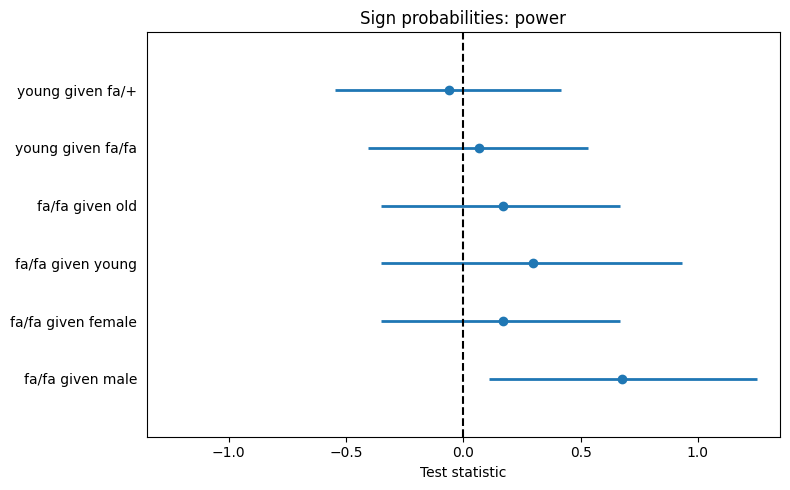

In [21]:
f, ax = plt.subplots(figsize=(8, 5))
ax = forestplot(ax, ts_power);
ax.set_title("Sign probabilities: power");
f.tight_layout()
f.savefig(PLOT_DIR / "ts_power.png", bbox_inches="tight", dpi=200)

## Blood pressure

In [22]:
msts_bp_vehicle = pl.read_csv(PREPARED_FILES["bp_vehicle"])
msts_bp_empa = pl.read_csv(PREPARED_FILES["bp_empa"])
msts_bp_vehicle.describe()

statistic,,rat,gtyp,age,sex,treatment,bp_baseline,bp_change,bp_injected,log_bp_baseline,log_bp_injected,log_bp_baseline_std,log_bp_change
str,f64,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""",34.0,"""34""","""34""","""34""","""34""","""34""",34.0,34.0,34.0,34.0,34.0,34.0,34.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",403.058824,null,null,null,null,null,123.427017,3.935423,127.36244,4.813868,4.844778,-0.120778,0.03091
"""std""",233.659288,null,null,null,null,null,7.489972,5.255136,8.564283,0.060578,0.068773,0.773612,0.043617
"""min""",15.0,"""20240813a""","""fa/+""","""Adult""","""F""","""Vehicle""",109.07689,-11.98913,103.76452,4.692053,4.642124,-1.676413,-0.10934
"""25%""",202.0,null,null,null,null,null,116.84752,1.82411,121.22905,4.76087,4.797682,-0.797586,0.014409
"""50%""",412.0,null,null,null,null,null,123.03403,5.519496,128.25748,4.812461,4.85404,-0.13874,0.044119
"""75%""",594.0,null,null,null,null,null,128.9717,6.87104,134.86777,4.859593,4.904295,0.46316,0.053921
"""max""",814.0,"""20241030b""","""fa/fa""","""Young""","""M""","""Vehicle""",137.77512,12.7811,141.38322,4.925623,4.951474,1.306396,0.103804


In [23]:
idata_bp_empa = az.from_netcdf(RESULTS_DIR / "idata_bp_empa_log.nc")
idata_bp_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bp_vehicle_log.nc")
idata_bp_empa

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [24]:
az.summary(idata_bp_empa, var_names=["~mu", "~1|rat"])

/Users/tedgro/repos/teddygroves/kidney/.venv/lib/python3.13/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.038,0.005,0.029,0.048,0.000,0.0,3498.0,2849.0,1.0
Intercept,0.029,0.014,0.004,0.054,0.000,0.0,2865.0,3158.0,1.0
gtyp[fa/fa],-0.046,0.020,-0.085,-0.009,0.000,0.0,2677.0,2895.0,1.0
age[Young],0.002,0.020,-0.037,0.037,0.000,0.0,2460.0,2689.0,1.0
sex[M],-0.019,0.019,-0.054,0.016,0.000,0.0,2693.0,2891.0,1.0
"gtyp:age[fa/fa, Young]",0.019,0.027,-0.031,0.073,0.001,0.0,2206.0,2738.0,1.0
"gtyp:sex[fa/fa, M]",-0.040,0.026,-0.089,0.009,0.001,0.0,2562.0,2736.0,1.0


In [25]:
az.summary(idata_bp_vehicle, var_names=["~mu", "~1|rat"])

/Users/tedgro/repos/teddygroves/kidney/.venv/lib/python3.13/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.045,0.006,0.035,0.056,0.000,0.0,3475.0,2205.0,1.0
Intercept,0.041,0.016,0.010,0.071,0.000,0.0,2925.0,3218.0,1.0
gtyp[fa/fa],0.009,0.024,-0.035,0.056,0.000,0.0,2476.0,2512.0,1.0
age[Young],0.004,0.024,-0.045,0.046,0.000,0.0,2707.0,2875.0,1.0
sex[M],-0.009,0.023,-0.054,0.033,0.000,0.0,2637.0,3159.0,1.0
"gtyp:age[fa/fa, Young]",-0.034,0.032,-0.095,0.026,0.001,0.0,2520.0,2941.0,1.0
"gtyp:sex[fa/fa, M]",-0.015,0.031,-0.074,0.043,0.001,0.0,2398.0,2615.0,1.0


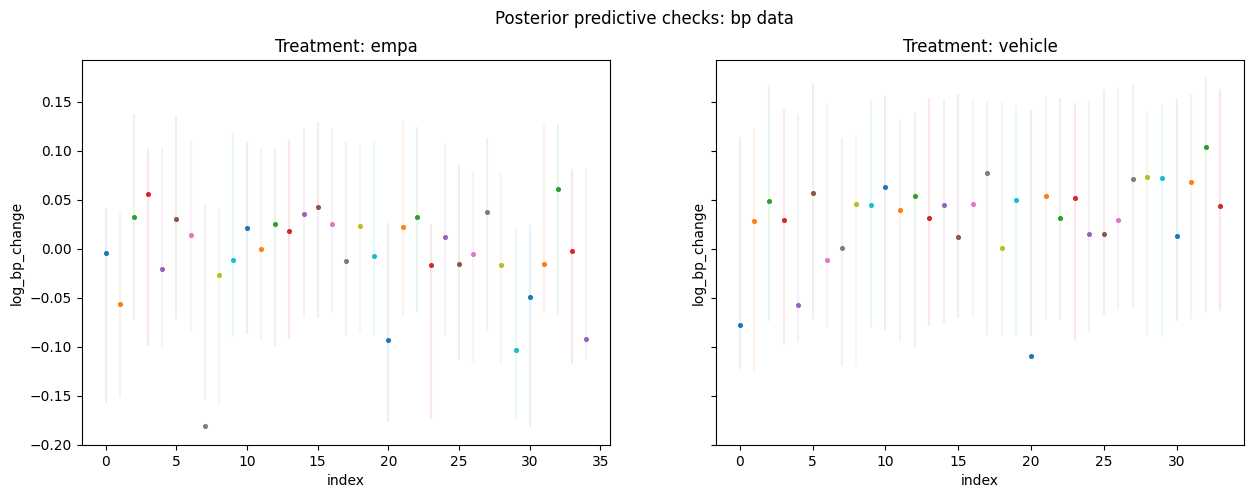

In [26]:
f, axes = plt.subplots(1, 2, figsize=[15, 5], sharey=True)
axes[0] = plot_ppc(axes[0], idata_bp_empa, msts_bp_empa, ycol="log_bp_change", groupcol="rat")
axes[0].set_title("Treatment: empa");
axes[0].get_legend().remove()

axes[1] = plot_ppc(axes[1], idata_bp_vehicle, msts_bp_vehicle, ycol="log_bp_change", groupcol="rat")
axes[1].set_title("Treatment: vehicle");
axes[1].get_legend().remove()

f.suptitle("Posterior predictive checks: bp data");
f.savefig(PLOT_DIR / "ppc_bp.png", bbox_inches="tight", dpi=200)

In [27]:
t_groups_empa, t_groups_vehicle = (
    {
        "fa/fa:young": idata.posterior["age"] + idata.posterior["gtyp"] + idata.posterior["gtyp:age"],
        "fa/fa:old": idata.posterior["gtyp"],
        "fa/+:old": 0.0,
        "fa/+:young": idata.posterior["age"],    
    } 
    for idata in (idata_bp_empa, idata_bp_vehicle)
)
ts_empa, ts_vehicle = (
    {
        "fa/fa given young": t_groups["fa/fa:young"] - t_groups["fa/+:young"],
        "fa/fa given old": t_groups["fa/fa:old"] - t_groups["fa/+:old"],
        "young given fa/fa": t_groups["fa/fa:young"] - t_groups["fa/fa:old"],
        "young given fa/+": t_groups["fa/+:young"] - t_groups["fa/+:old"],
    }
    for t_groups in (t_groups_empa, t_groups_vehicle)
)
def get_sign_probs(ts):
    return {k: (v>0).mean().item() for k, v in ts.items()}

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa given young': 0.15025,
 'fa/fa given old': 0.0125,
 'young given fa/fa': 0.86375,
 'young given fa/+': 0.5345}


Vehicle sign probabilities:


{'fa/fa given young': 0.2025,
 'fa/fa given old': 0.646,
 'young given fa/fa': 0.0905,
 'young given fa/+': 0.57875}

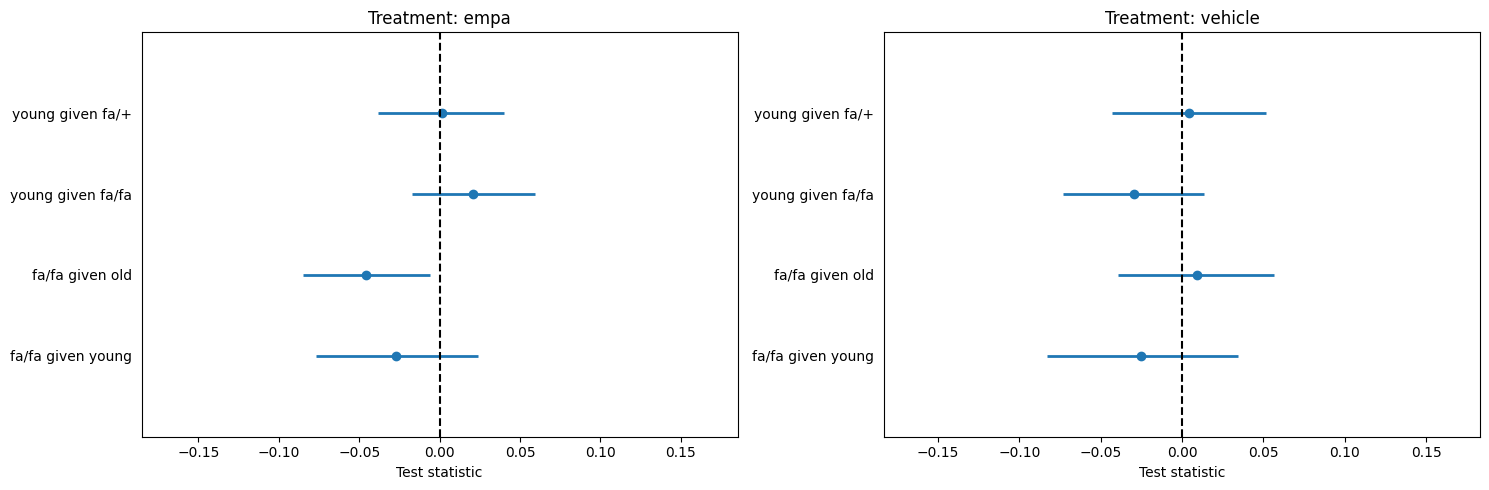

In [28]:
f, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0] = forestplot(axes[0], ts_empa);
axes[0].set_title("Treatment: empa");

axes[1] = forestplot(axes[1], ts_vehicle);
axes[1].set_title("Treatment: vehicle");

f.tight_layout()
f.savefig(PLOT_DIR / "ts_bp.png", bbox_inches="tight", dpi=200)